# 🛒 Olist Brazilian E-Commerce — Professional Data Analysis

---

## Project Overview

This notebook presents a structured, end-to-end analysis of the **Olist Brazilian E-Commerce dataset** — a real-world dataset from Brazil's largest department store marketplace. The data spans **September 2016 to October 2018** and covers the complete order lifecycle: from purchase to delivery, payment, product, customer, seller, and review.

### Business Context
Olist connects small businesses across Brazil to major retail channels via a single contract. Merchants list products and Olist handles fulfillment logistics, customer communication, and after-sale reviews.

### Analytical Goals
- Understand sales trends, revenue patterns, and growth trajectory
- Identify top-performing product categories and sellers
- Evaluate customer satisfaction through review scores
- Analyze delivery performance and logistics bottlenecks
- Uncover geographic patterns in customer and seller distribution
- Generate actionable business recommendations

---

## Dataset Summary

| Dataset | Rows | Key Info |
|---|---|---|
| `olist_orders_dataset` | 99,441 | Order lifecycle + timestamps |
| `olist_order_items_dataset` | 112,650 | Products per order, prices, freight |
| `olist_order_payments_dataset` | 103,886 | Payment method, installments, value |
| `olist_order_reviews_dataset` | 99,224 | Customer satisfaction scores & comments |
| `olist_products_dataset` | 32,951 | Product attributes, dimensions, category |
| `olist_customers_dataset` | 99,441 | Customer location data |
| `olist_sellers_dataset` | 3,095 | Seller location data |
| `olist_geolocation_dataset` | 1,000,163 | ZIP → lat/lng mapping |
| `product_category_name_translation` | 71 | Portuguese → English category names |

---

## 📦 Section 1 — Dataset Descriptions

### 1.1 Orders Dataset (`olist_orders_dataset`)
The **central table** of the schema. Every order has a unique `order_id` and links to a `customer_id`. Tracks the full lifecycle with timestamps:
- `order_purchase_timestamp` — when customer placed the order
- `order_approved_at` — payment approval time
- `order_delivered_carrier_date` — when dispatched to logistics partner
- `order_delivered_customer_date` — actual delivery date
- `order_estimated_delivery_date` — promised delivery date

⚠️ **Watch for:** ~4,900 null values in delivery timestamps (orders not yet delivered or canceled).

---

### 1.2 Order Items Dataset (`olist_order_items_dataset`)
One row per **item** within an order (an order can have multiple items). Key fields:
- `order_item_id` — item sequence within the order
- `product_id` / `seller_id` — links to product and seller tables
- `price` — item price (BRL)
- `freight_value` — shipping cost for that item

✅ **No nulls.** Clean and complete.

---

### 1.3 Order Payments Dataset (`olist_order_payments_dataset`)
Records how each order was paid. One order can have **multiple payment rows** (e.g., partial voucher + credit card).
- `payment_type` — credit_card, boleto, voucher, debit_card
- `payment_installments` — number of installments chosen
- `payment_value` — amount paid in that row

💡 Credit cards dominate (~74%), followed by boleto (~19%) — a Brazilian bank slip payment method.

---

### 1.4 Order Reviews Dataset (`olist_order_reviews_dataset`)
Post-delivery customer feedback. Contains ~145,000 null values — primarily in optional comment fields (`review_comment_title`, `review_comment_message`). The score itself is complete.
- `review_score` — 1–5 star rating
- `review_comment_message` — optional free-text feedback
- `review_creation_date` / `review_answer_timestamp` — survey timing

📊 Average score: **4.09 / 5.0**. ~58% of reviews are 5-star.

---

### 1.5 Products Dataset (`olist_products_dataset`)
Product catalog with physical attributes and category. ~2,400 nulls in category and dimension fields.
- `product_category_name` — Portuguese category name (join with translation table)
- `product_photos_qty` — number of listing photos
- Physical dimensions: weight (g), length/height/width (cm)

---

### 1.6 Sellers Dataset (`olist_sellers_dataset`)
3,095 unique sellers. Fully clean with no nulls.
- `seller_zip_code_prefix` — for geolocation join
- `seller_city` / `seller_state` — geographic distribution

📍 São Paulo (SP) dominates with ~60% of all sellers.

---

### 1.7 Customers Dataset (`olist_customers_dataset`)
99,441 customer records, no nulls. Note: `customer_id` is order-level (same person reordering gets a new `customer_id`), while `customer_unique_id` is the true unique customer.
- Important distinction for repeat purchase analysis!

---

### 1.8 Geolocation Dataset (`olist_geolocation_dataset`)
Maps Brazilian ZIP code prefixes to lat/lng coordinates. Largest table (1M+ rows) — use carefully to avoid memory issues. Join on `geolocation_zip_code_prefix`.

---

### 1.9 Category Name Translation (`product_category_name_translation`)
Simple 71-row lookup table mapping Portuguese category names to English equivalents. Always join this before any category-level analysis.

## ❓ Section 2 — Business Questions to Answer

The analysis is structured around **5 themes** with specific questions under each:

### Theme A — Sales & Revenue
1. What is the monthly revenue trend over the dataset period?
2. Which months and seasons show peak order volume?
3. What is the average order value (AOV), and how does it vary by state?
4. How much revenue does freight contribute vs. product price?

### Theme B — Product & Category Performance
5. Which product categories generate the most revenue?
6. Which categories have the highest average item price?
7. Which categories have the most orders?
8. Is there a relationship between number of product photos and review score?

### Theme C — Customer Satisfaction
9. What is the overall distribution of review scores?
10. Which product categories have the lowest average review scores?
11. Does late delivery correlate with lower review scores?
12. What percentage of orders were delivered on time vs. late?

### Theme D — Sellers & Geography
13. Which states have the most sellers and most customers?
14. Which sellers generate the highest revenue?
15. Is there a seller concentration risk (few sellers = most revenue)?
16. What is the average seller-to-customer distance for orders?

### Theme E — Payments & Behavior
17. What is the most common payment method?
18. How many installments do customers typically choose for credit card payments?
19. Do higher-value orders use more installments?
20. What share of orders use multiple payment methods?

---

## 🔧 Section 3 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [3]:
orders = pd.read_csv('data/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp','order_approved_at',
    'order_delivered_carrier_date','order_delivered_customer_date',
    'order_estimated_delivery_date'])

items = pd.read_csv('data/olist_order_items_dataset.csv',
    parse_dates=['shipping_limit_date'])

payments = pd.read_csv('data/olist_order_payments_dataset.csv')

reviews = pd.read_csv('data/olist_order_reviews_dataset.csv',
    parse_dates=['review_creation_date','review_answer_timestamp'])

products = pd.read_csv('data/olist_products_dataset.csv')

sellers = pd.read_csv('data/olist_sellers_dataset.csv')

category = pd.read_csv('data/product_category_name_translation.csv')

customers = pd.read_csv('data/olist_customers_dataset.csv')

# Geolocation is large — load carefully
geo = pd.read_csv('data/olist_geolocation_dataset.csv')

# Translate product categories to English
products = products.merge(category, on='product_category_name', how='left')

print('All datasets loaded ✅')

print(f'Orders date range: {orders.order_purchase_timestamp.min().date()} '
      f'→ {orders.order_purchase_timestamp.max().date()}')

All datasets loaded ✅
Orders date range: 2016-09-04 → 2018-10-17


In [4]:
# ── Quick shape + null summary ─────────────────────────────────────
datasets = {
    'orders': orders, 'items': items, 'payments': payments,
    'reviews': reviews, 'products': products, 'sellers': sellers,
    'customers': customers, 'geo': geo
}

summary = pd.DataFrame({
    'rows': {k: v.shape[0] for k, v in datasets.items()},
    'cols': {k: v.shape[1] for k, v in datasets.items()},
    'nulls': {k: v.isnull().sum().sum() for k, v in datasets.items()}
})
summary

,rows,cols,nulls
orders,99441,8,4908
items,112650,7,0
payments,103886,5,0
reviews,99224,7,145903
products,32951,10,3071
sellers,3095,4,0
customers,99441,5,0
geo,1000163,5,0


---

## 📊 Section 4 — Sales & Revenue Analysis

### Q1 & Q2: Monthly Revenue Trend & Seasonality

Peak revenue month: 2017-11
Peak order month:   2017-11


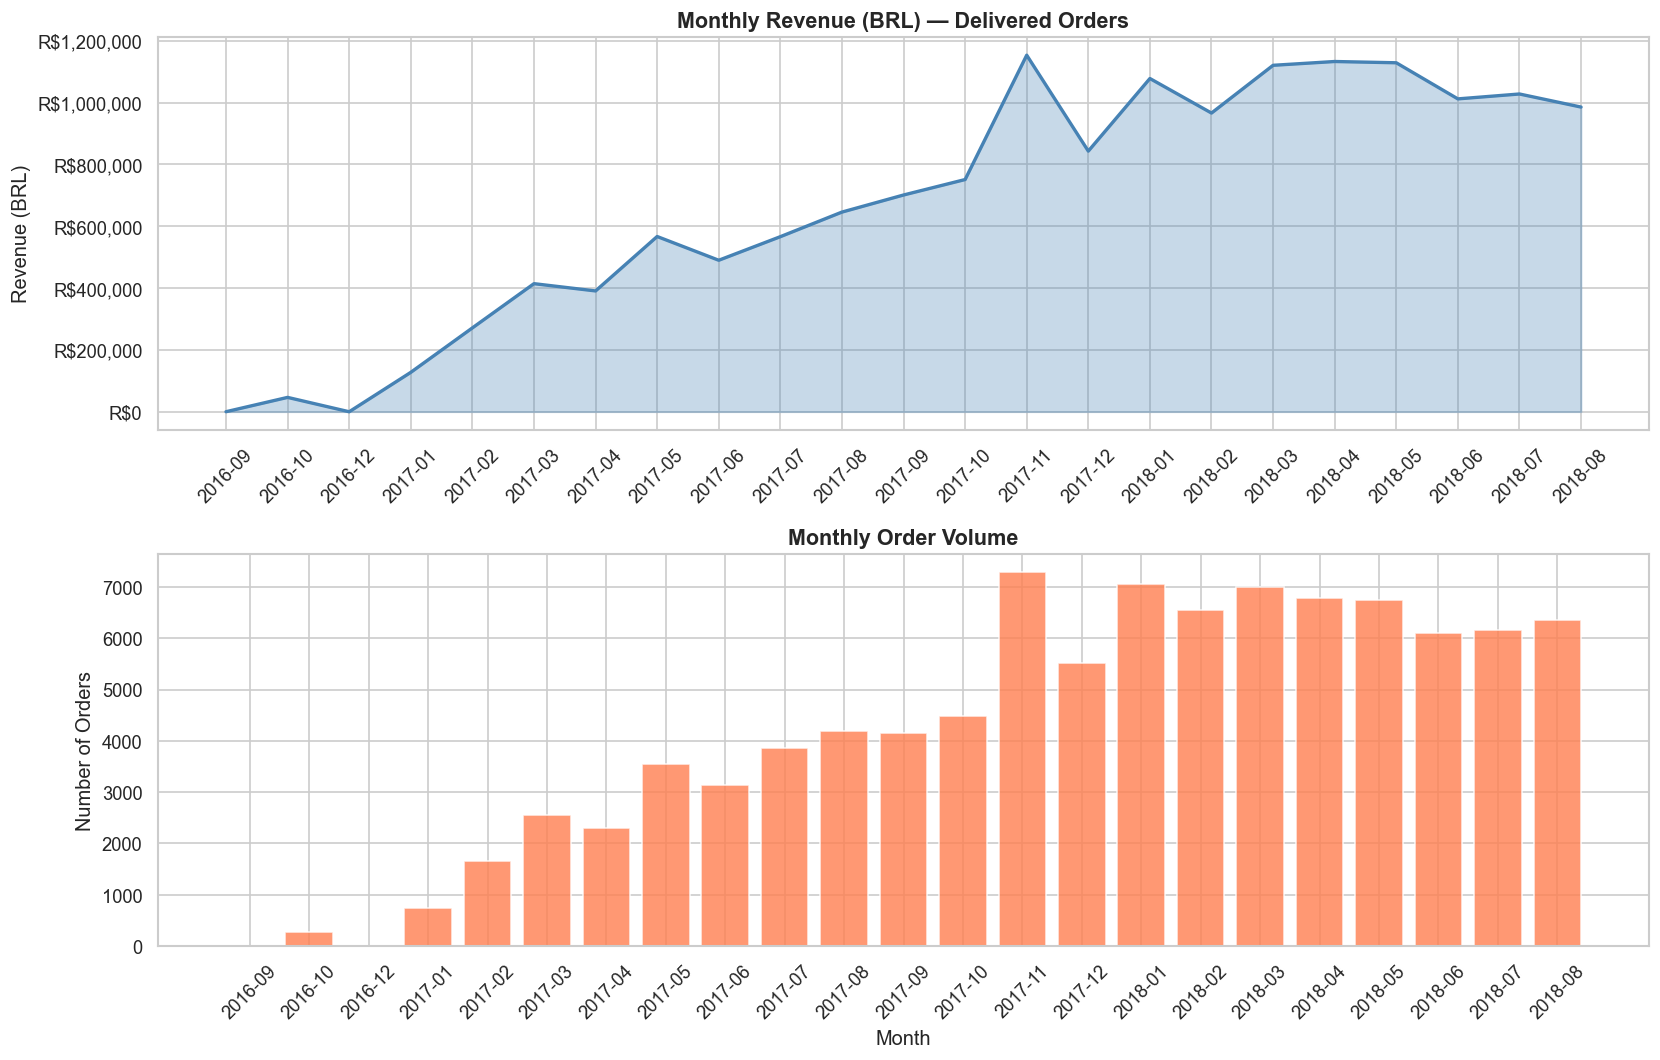

In [12]:
# Build master order-level revenue table
order_revenue = (
    items.groupby('order_id')
         .agg(item_revenue=('price', 'sum'), freight_revenue=('freight_value', 'sum'),
              item_count=('order_item_id', 'count'))
         .reset_index()
)
order_revenue['total_revenue'] = order_revenue['item_revenue'] + order_revenue['freight_revenue']

# Merge with order timestamps
df = orders[['order_id','order_purchase_timestamp','order_status']].merge(
         order_revenue, on='order_id', how='left')
df = df[df['order_status'] == 'delivered'].copy()  # Only completed orders
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    revenue=('total_revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Revenue chart
axes[0].fill_between(monthly['year_month_str'], monthly['revenue'], alpha=0.3, color='steelblue')
axes[0].plot(monthly['year_month_str'], monthly['revenue'], color='steelblue', linewidth=2)
axes[0].set_title('Monthly Revenue (BRL) — Delivered Orders', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('')

# Order volume chart
axes[1].bar(monthly['year_month_str'], monthly['orders'], color='coral', alpha=0.8)
axes[1].set_title('Monthly Order Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Month')

plt.tight_layout()


print(f"Peak revenue month: {monthly.loc[monthly.revenue.idxmax(), 'year_month_str']}")
print(f"Peak order month:   {monthly.loc[monthly.orders.idxmax(), 'year_month_str']}")
plt.savefig("chart/Monthly Revenue(BRL)-Delivered Orders")
plt.show()

### Q3 & Q4: Average Order Value (AOV) and Freight vs. Price Split

Average Order Value (AOV):     R$159.83
Avg Freight as % of Order:     20.9%



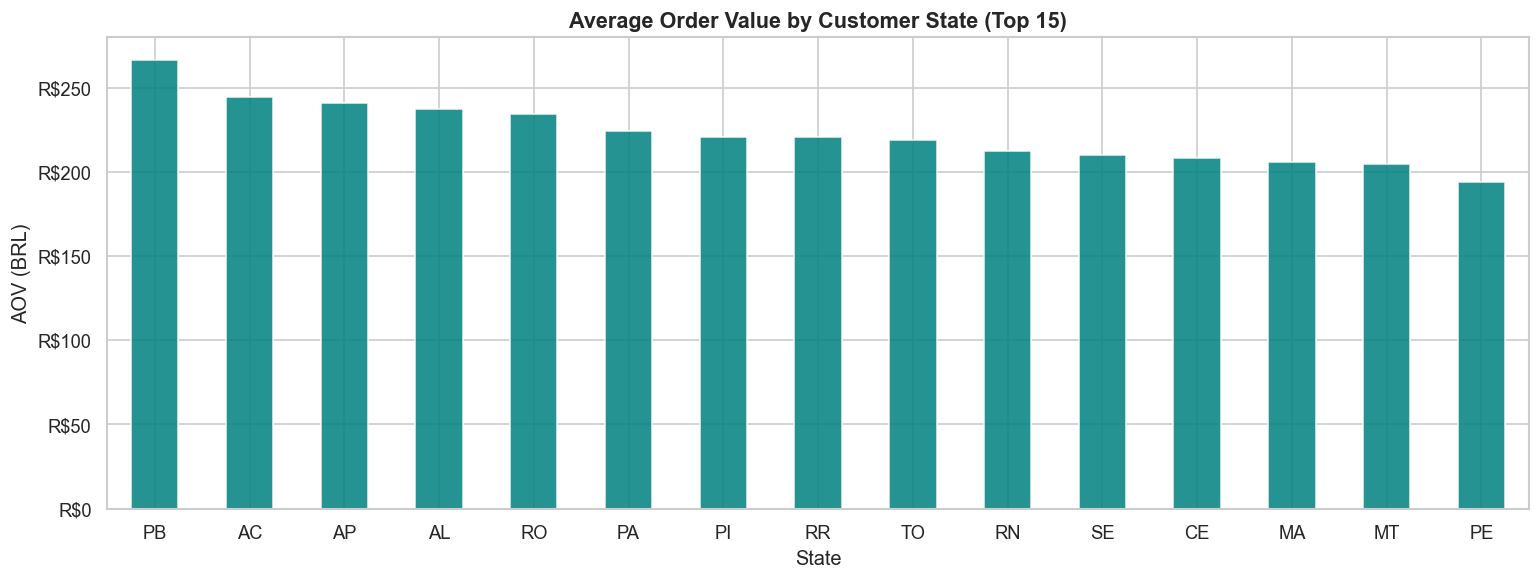

In [13]:
aov = df['total_revenue'].mean()
avg_freight_pct = (df['freight_revenue'] / df['total_revenue'] * 100).mean()

print(f'Average Order Value (AOV):     R${aov:,.2f}')
print(f'Avg Freight as % of Order:     {avg_freight_pct:.1f}%')
print()


df_state = df.merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)
# AOV by customer state
df_state = df_state.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)
aov_state = df_state.groupby('customer_state')['total_revenue'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 5))
aov_state.plot(kind='bar', ax=ax, color='teal', alpha=0.85, edgecolor='white')
ax.set_title('Average Order Value by Customer State (Top 15)', fontsize=13, fontweight='bold')
ax.set_ylabel('AOV (BRL)')
ax.set_xlabel('State')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart/Average Order Value by Customer State")
plt.show()

---

## 🏷️ Section 5 — Product & Category Analysis

### Q5–Q7: Revenue, Price, and Volume by Category

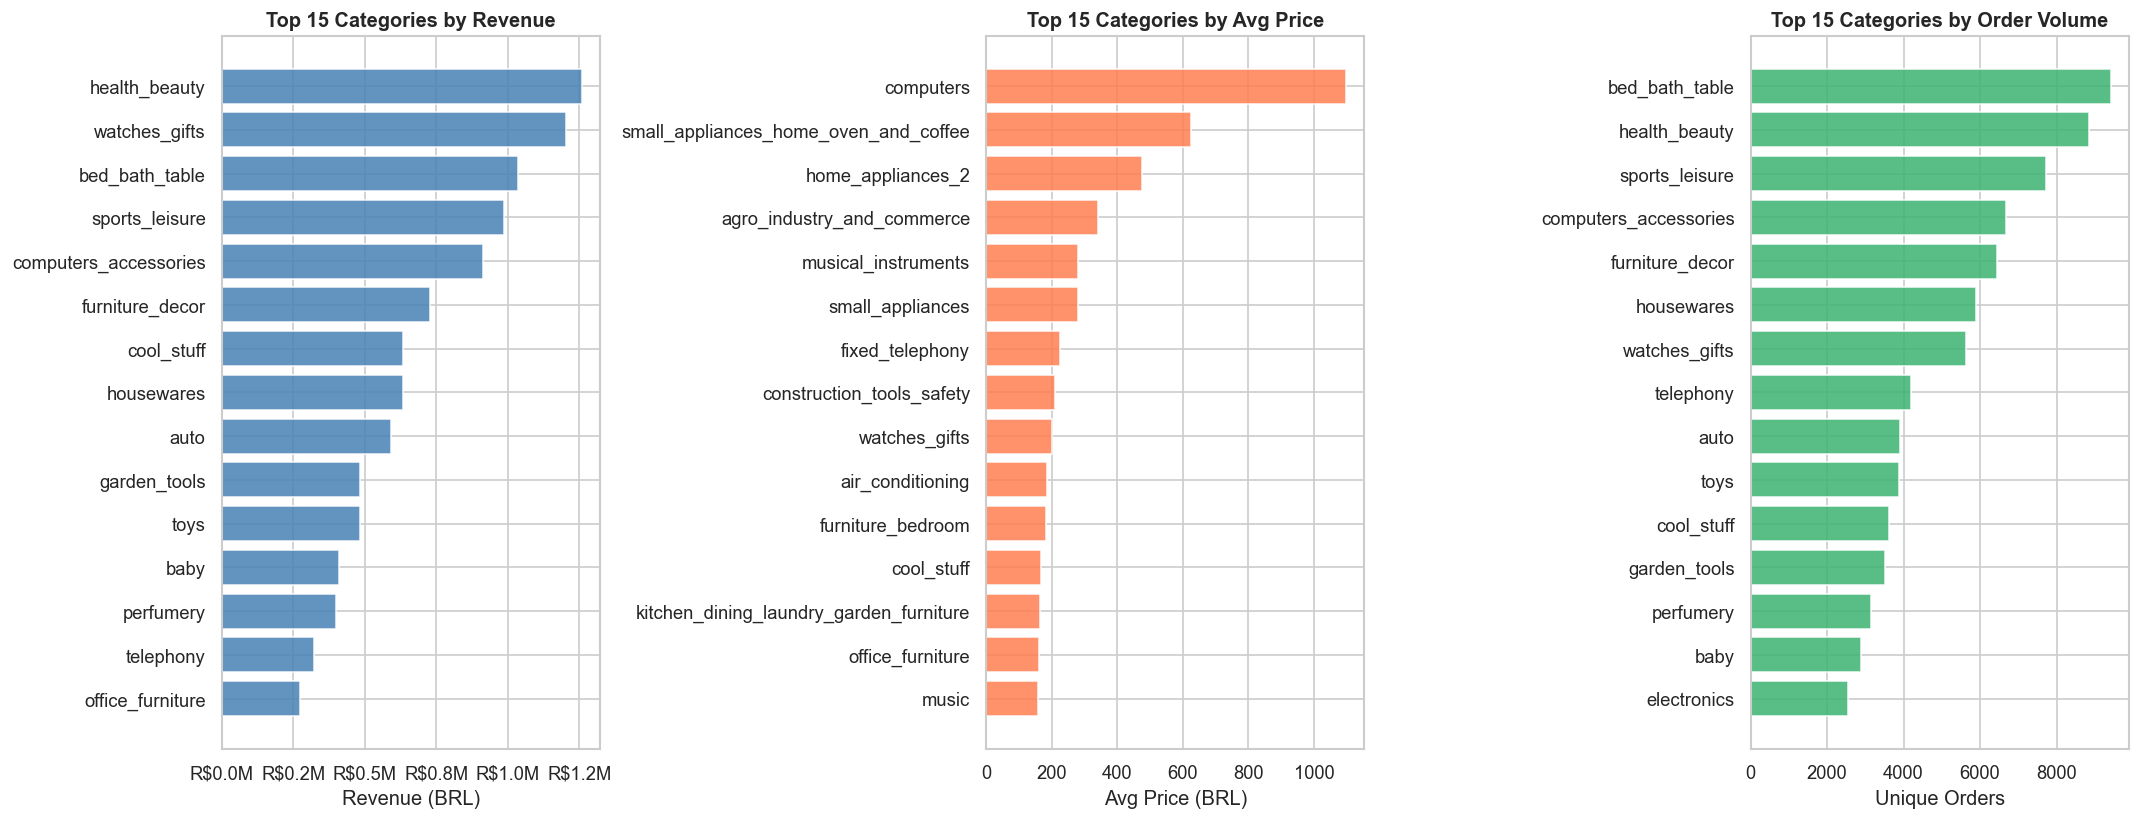

In [14]:
# Join items with product categories
items_cat = items.merge(products[['product_id','product_category_name_english']], 
                        on='product_id', how='left')
items_cat['category'] = items_cat['product_category_name_english'].fillna('Unknown')

cat_stats = items_cat.groupby('category').agg(
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    order_count=('order_id', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Revenue
top_rev = cat_stats.head(top_n)
axes[0].barh(top_rev['category'][::-1], top_rev['total_revenue'][::-1], color='steelblue', alpha=0.85)
axes[0].set_title('Top 15 Categories by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (BRL)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# Average price
top_price = cat_stats.sort_values('avg_price', ascending=False).head(top_n)
axes[1].barh(top_price['category'][::-1], top_price['avg_price'][::-1], color='coral', alpha=0.85)
axes[1].set_title('Top 15 Categories by Avg Price', fontweight='bold')
axes[1].set_xlabel('Avg Price (BRL)')

# Order count
top_vol = cat_stats.sort_values('order_count', ascending=False).head(top_n)
axes[2].barh(top_vol['category'][::-1], top_vol['order_count'][::-1], color='mediumseagreen', alpha=0.85)
axes[2].set_title('Top 15 Categories by Order Volume', fontweight='bold')
axes[2].set_xlabel('Unique Orders')

plt.tight_layout()
plt.savefig("chart/Revenue,Price, and volume by Category")
plt.show()

### Q8: Photos vs. Review Score Correlation

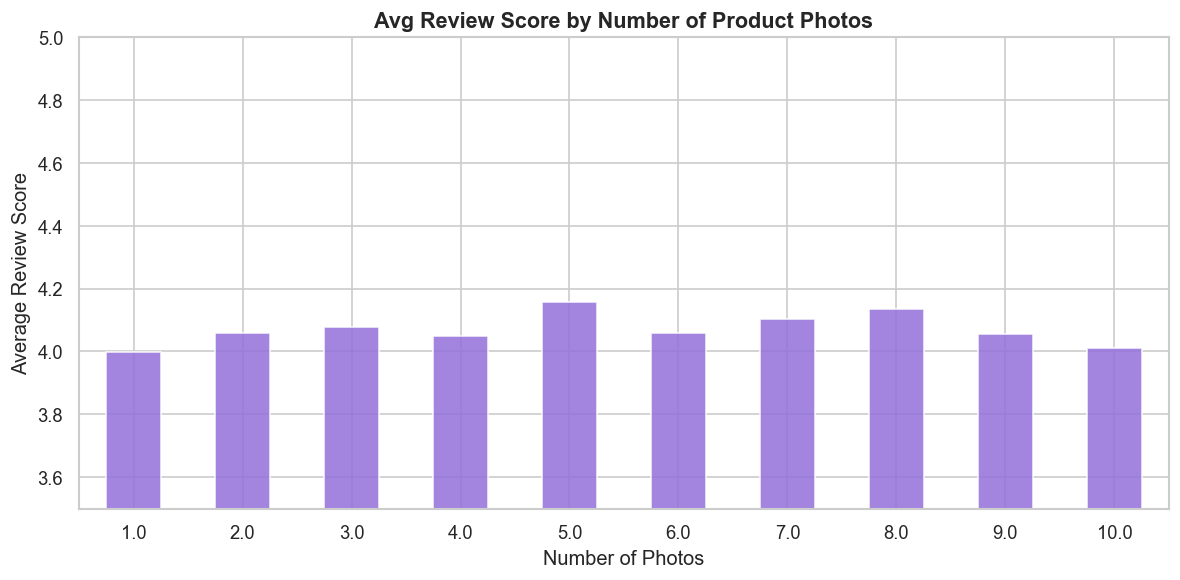

Pearson correlation (photos vs score): 0.023


In [ ]:
# Join reviews → orders → items → products
photo_review = (
    reviews[['order_id','review_score']]
    .merge(items[['order_id','product_id']], on='order_id', how='left')
    .merge(products[['product_id','product_photos_qty']], on='product_id', how='left')
    .dropna(subset=['product_photos_qty'])
)
photo_review['product_photos_qty'] = photo_review['product_photos_qty'].clip(upper=10)

avg_score_by_photos = photo_review.groupby('product_photos_qty')['review_score'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
avg_score_by_photos.plot(kind='bar', ax=ax, color='mediumpurple', alpha=0.85, edgecolor='white')
ax.set_title('Avg Review Score by Number of Product Photos', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Photos')
ax.set_ylabel('Average Review Score')
ax.set_ylim(3.5, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

corr = photo_review[['product_photos_qty','review_score']].corr().iloc[0, 1]
print(f'Pearson correlation (photos vs score): {corr:.3f}')

---

## ⭐ Section 6 — Customer Satisfaction Analysis

### Q9: Review Score Distribution

Mean score: 4.09 | Median: 5.0


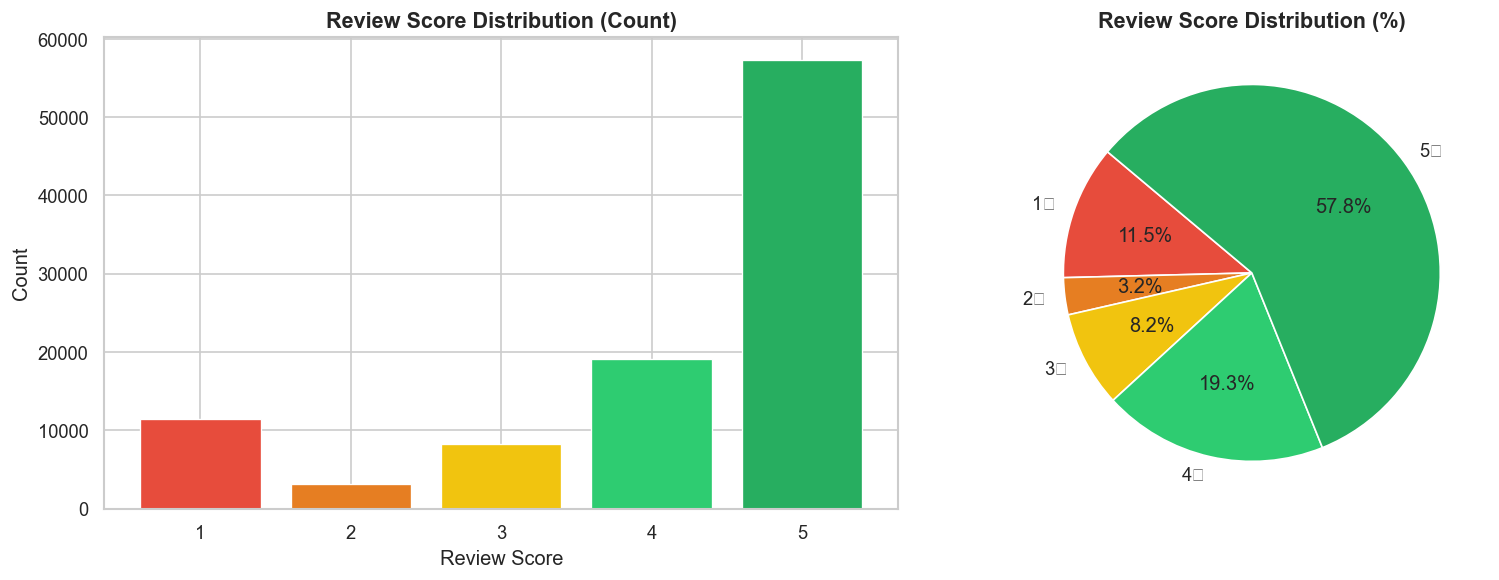

In [15]:
score_counts = reviews['review_score'].value_counts().sort_index()
score_pct = score_counts / score_counts.sum() * 100

colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Review Score Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')

axes[1].pie(score_pct, labels=[f'{i}★' for i in score_pct.index],
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Review Score Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
print(f'Mean score: {reviews["review_score"].mean():.2f} | Median: {reviews["review_score"].median()}')
plt.savefig("chart/Review Score Distrbution")
plt.show()

### Q10: Worst-Rated Product Categories

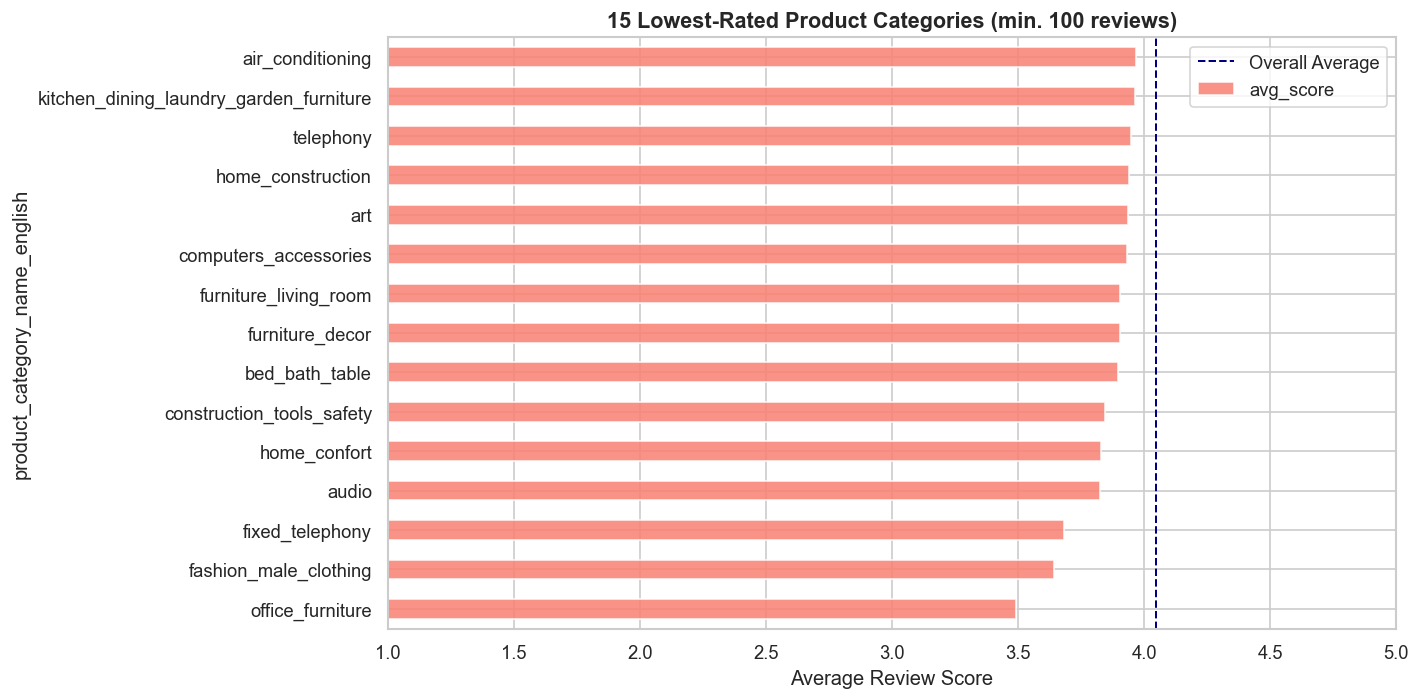

In [16]:
cat_reviews = (
    reviews[['order_id','review_score']]
    .merge(items[['order_id','product_id']], on='order_id', how='left')
    .merge(products[['product_id','product_category_name_english']], on='product_id', how='left')
    .dropna(subset=['product_category_name_english'])
)

cat_score = (
    cat_reviews.groupby('product_category_name_english')
               .agg(avg_score=('review_score','mean'), review_count=('review_score','count'))
               .query('review_count >= 100')  # Minimum threshold
               .sort_values('avg_score')
)

fig, ax = plt.subplots(figsize=(12, 6))
worst = cat_score.head(15)
worst['avg_score'].plot(kind='barh', ax=ax, color='salmon', alpha=0.85)
ax.set_title('15 Lowest-Rated Product Categories (min. 100 reviews)', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Review Score')
ax.axvline(cat_score['avg_score'].mean(), color='navy', linestyle='--', linewidth=1.2, label='Overall Average')
ax.legend()
ax.set_xlim(1, 5)
plt.tight_layout()
plt.savefig("chart/15 Lowest-Rated Product Categories")
plt.show()

### Q11 & Q12: Delivery Performance & Its Impact on Reviews

On-time delivery rate: 93.2%
Late delivery rate:    6.8%
Avg delay (late only): 10.6 days


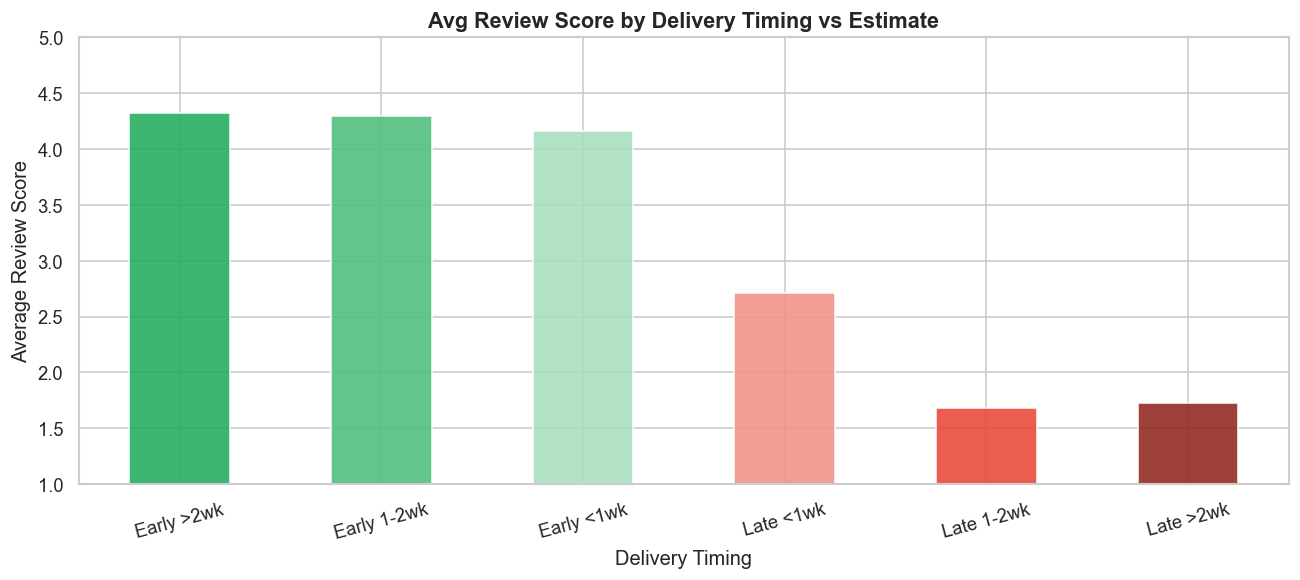

In [ ]:
# Calculate delivery delay
orders_del = orders.dropna(subset=['order_delivered_customer_date','order_estimated_delivery_date']).copy()
orders_del['delay_days'] = (
    (orders_del['order_delivered_customer_date'] - orders_del['order_estimated_delivery_date'])
    .dt.days
)
orders_del['is_late'] = orders_del['delay_days'] > 0
on_time_pct = (~orders_del['is_late']).mean() * 100

print(f'On-time delivery rate: {on_time_pct:.1f}%')
print(f'Late delivery rate:    {100-on_time_pct:.1f}%')
print(f'Avg delay (late only): {orders_del[orders_del.is_late]["delay_days"].mean():.1f} days')

# Delay vs review score
delay_review = orders_del[['order_id','delay_days','is_late']].merge(
    reviews[['order_id','review_score']], on='order_id', how='inner')

delay_review['delay_bucket'] = pd.cut(
    delay_review['delay_days'],
    bins=[-100, -14, -7, 0, 7, 14, 200],
    labels=['Early >2wk','Early 1-2wk','Early <1wk','Late <1wk','Late 1-2wk','Late >2wk'])

bucket_score = delay_review.groupby('delay_bucket', observed=True)['review_score'].mean()

fig, ax = plt.subplots(figsize=(11, 5))
colors_b = ['#27ae60','#52be80','#a9dfbf','#f1948a','#e74c3c','#922b21']
bucket_score.plot(kind='bar', ax=ax, color=colors_b, edgecolor='white', alpha=0.9)
ax.set_title('Avg Review Score by Delivery Timing vs Estimate', fontsize=13, fontweight='bold')
ax.set_xlabel('Delivery Timing')
ax.set_ylabel('Average Review Score')
ax.set_ylim(1, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---

## 🗺️ Section 7 — Geographic & Seller Analysis

### Q13: Seller and Customer Distribution by State

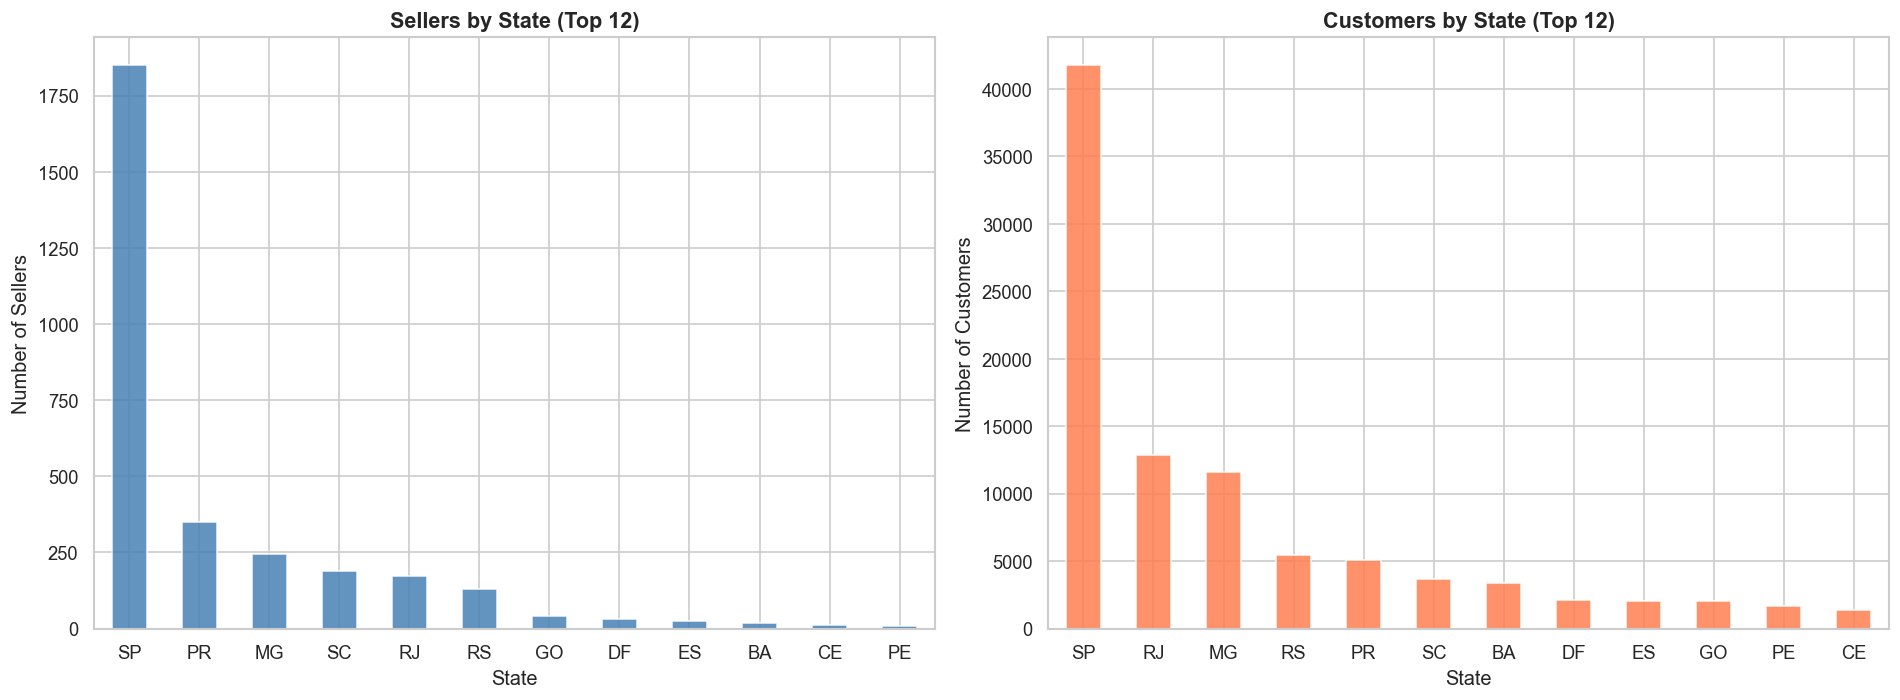

<Figure size 1440x600 with 0 Axes>

In [11]:
seller_state = sellers['seller_state'].value_counts().head(12)
customer_state = customers['customer_state'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
seller_state.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Sellers by State (Top 12)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Sellers')
axes[0].set_xlabel('State')
axes[0].tick_params(axis='x', rotation=0)

customer_state.plot(kind='bar', ax=axes[1], color='coral', alpha=0.85, edgecolor='white')
axes[1].set_title('Customers by State (Top 12)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xlabel('State')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
plt.savefig("chart/Sellers by State(Top 12) and  Customers By State")

### Q14 & Q15: Top Sellers by Revenue & Concentration Risk

Top 10 sellers → 13.1% of total revenue
Top 20% sellers → 82.7% of total revenue (Pareto check)


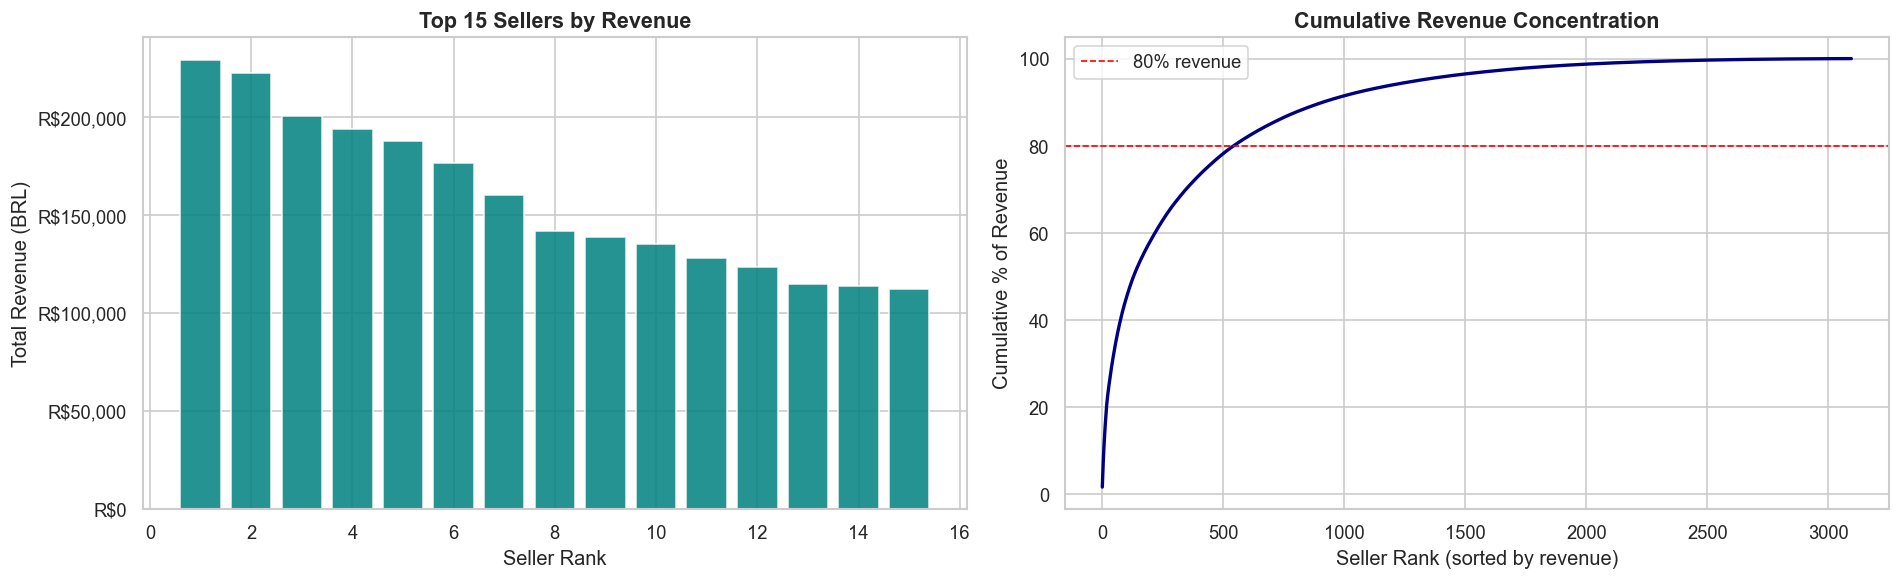

<Figure size 1440x600 with 0 Axes>

In [10]:
seller_revenue = (
    items.groupby('seller_id')
         .agg(total_revenue=('price','sum'), order_count=('order_id','nunique'))
         .sort_values('total_revenue', ascending=False)
         .reset_index()
)
seller_revenue['rank'] = range(1, len(seller_revenue)+1)
seller_revenue['cum_pct'] = seller_revenue['total_revenue'].cumsum() / seller_revenue['total_revenue'].sum() * 100

top20_pct = seller_revenue.head(int(len(seller_revenue)*0.2))['total_revenue'].sum() / seller_revenue['total_revenue'].sum() * 100
top10_sellers_pct = seller_revenue.head(10)['total_revenue'].sum() / seller_revenue['total_revenue'].sum() * 100
print(f'Top 10 sellers → {top10_sellers_pct:.1f}% of total revenue')
print(f'Top 20% sellers → {top20_pct:.1f}% of total revenue (Pareto check)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 sellers
top15 = seller_revenue.head(15)
axes[0].bar(top15['rank'], top15['total_revenue'], color='teal', alpha=0.85)
axes[0].set_title('Top 15 Sellers by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Seller Rank')
axes[0].set_ylabel('Total Revenue (BRL)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

# Lorenz-style cumulative curve
axes[1].plot(seller_revenue['rank'], seller_revenue['cum_pct'], color='navy', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='80% revenue')
axes[1].set_title('Cumulative Revenue Concentration', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Seller Rank (sorted by revenue)')
axes[1].set_ylabel('Cumulative % of Revenue')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig("chart/Top 15 Sellers by Revenue and Cumalative Revenue Concentration")

---

## 💳 Section 8 — Payment Behavior Analysis

### Q17–Q20: Payment Methods, Installments & Multi-Payment Orders

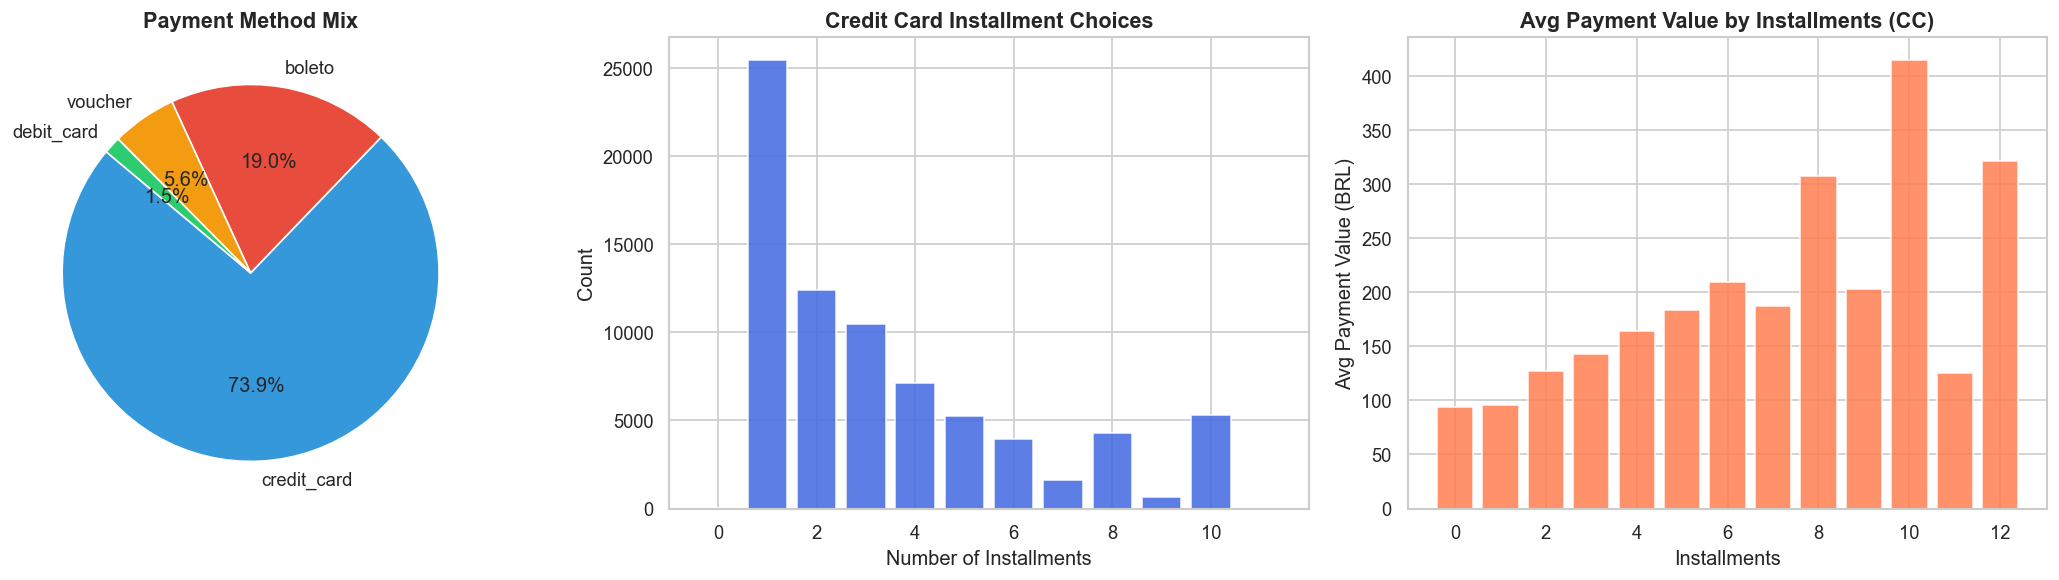

Orders with multiple payment methods: 3.1%


In [ ]:
# Payment type distribution
pay_type = payments[payments['payment_type'] != 'not_defined']['payment_type'].value_counts()

# Installments for credit cards
cc_installments = payments[payments['payment_type'] == 'credit_card']['payment_installments'].value_counts().sort_index().head(12)

# Multi-payment orders
multi_pay = payments.groupby('order_id')['payment_sequential'].max()
multi_pct = (multi_pay > 1).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Payment type pie
axes[0].pie(pay_type, labels=pay_type.index, autopct='%1.1f%%',
            colors=['#3498db','#e74c3c','#f39c12','#2ecc71'], startangle=140)
axes[0].set_title('Payment Method Mix', fontsize=13, fontweight='bold')

# Installments
axes[1].bar(cc_installments.index, cc_installments.values, color='royalblue', alpha=0.85, edgecolor='white')
axes[1].set_title('Credit Card Installment Choices', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Count')

# Installments vs order value
cc_data = payments[payments['payment_type'] == 'credit_card'].copy()
cc_data = cc_data[cc_data['payment_installments'] <= 12]
install_value = cc_data.groupby('payment_installments')['payment_value'].mean()
axes[2].bar(install_value.index, install_value.values, color='coral', alpha=0.85, edgecolor='white')
axes[2].set_title('Avg Payment Value by Installments (CC)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Installments')
axes[2].set_ylabel('Avg Payment Value (BRL)')

plt.tight_layout()
plt.show()
print(f'Orders with multiple payment methods: {multi_pct:.1f}%')

---

## 💡 Section 9 — Key Findings & Business Recommendations

### 📌 Summary of Key Findings

| Theme | Finding |
|---|---|
| Revenue | Strong growth trajectory from 2016→2018 with visible seasonal peaks |
| Categories | Health & Beauty, Computers/Electronics drive highest revenue |
| Satisfaction | 4.09/5.0 avg score; late delivery is the #1 driver of poor reviews |
| Geography | São Paulo dominates both sellers (60%) and customers (42%) |
| Payments | Credit card (~74%) is dominant; high installment usage reflects Brazilian credit culture |
| Sellers | Top 10 sellers account for a significant revenue share — concentration risk |

---

### ✅ Actionable Recommendations

**1. Improve Logistics & Delivery Accuracy**
> Late deliveries are the single strongest predictor of 1-star reviews. Partnering with more regional carriers or warehousing stock closer to northern/northeastern states could reduce delays and boost satisfaction scores.

**2. Diversify Seller Base Geographically**
> São Paulo concentration creates supply-side risk. Actively onboarding sellers in RJ, MG, RS would reduce shipping distances and freight costs for a large portion of customers.

**3. Invest in Low-Performing Categories**
> Categories with below-average review scores (e.g., office furniture, security/services) likely have product quality or logistics issues. Stricter seller vetting or category-specific policies could help.

**4. Leverage High-Installment Shoppers**
> Customers choosing 10–12 installment plans have significantly higher order values. Targeted promotions for high-ticket items (electronics, furniture) offering extended installments could increase AOV.

**5. Improve Product Listings**
> Products with more photos correlate with higher review scores — possibly because better-informed buyers have more accurate expectations. Mandate minimum photo counts for sellers.

**6. Reduce Seller Revenue Concentration Risk**
> If a handful of top sellers exit the platform, revenue impact could be severe. Implement seller loyalty programs and ensure no single seller exceeds X% of category revenue.

**7. Re-engage Repeat Customers**
> The `customer_unique_id` field reveals true repeat customers. A targeted retention/loyalty program for repeat buyers (who already trust the platform) could have higher ROI than pure acquisition spend.